In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Connect to existing database
con = duckdb.connect("../data/processed/provider_quality.db")

# Quick check
print("Tables:", con.execute("SHOW TABLES").fetchall())

Tables: [('complications',), ('hospitals',)]


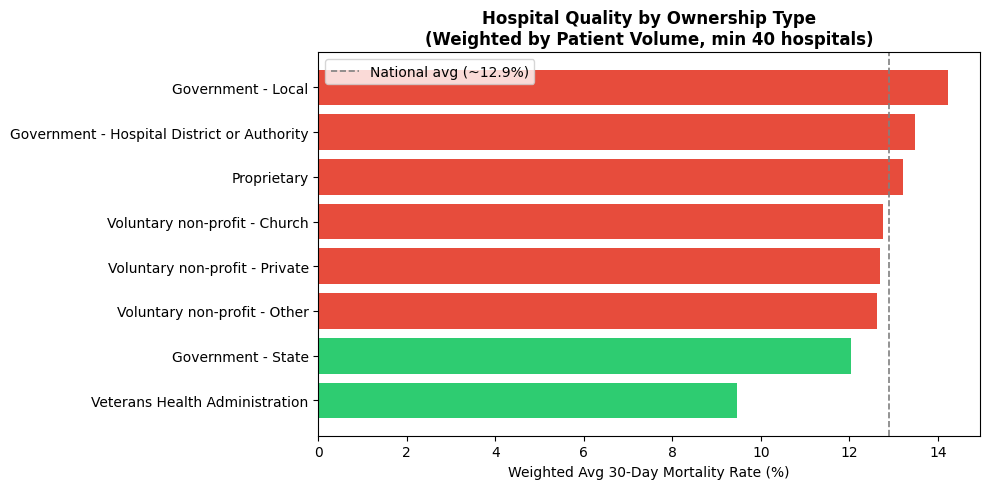

In [3]:
# Fetch ownership data
ownership = con.execute("""
    WITH mortality_measures AS (
        SELECT 
            c."Facility ID",
            h."Hospital Ownership",
            CAST(c."Score" AS FLOAT)        as score,
            CAST(c."Denominator" AS INTEGER) as denominator
        FROM complications c
        JOIN hospitals h ON c."Facility ID" = h."Facility ID"
        WHERE c."Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                                  'MORT_30_STK', 'MORT_30_COPD')
          AND c."Score" NOT IN ('Not Available', 'Not Applicable')
          AND c."Denominator" NOT IN ('Not Available', 'Not Applicable')
    )
    SELECT
        "Hospital Ownership",
        COUNT(DISTINCT "Facility ID")                          as num_hospitals,
        ROUND(SUM(score * denominator) / SUM(denominator), 2) as weighted_avg_mortality
    FROM mortality_measures
    GROUP BY "Hospital Ownership"
    HAVING COUNT(DISTINCT "Facility ID") >= 40
    ORDER BY weighted_avg_mortality ASC
""").df()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if x < 12.5 else '#e74c3c' for x in ownership['weighted_avg_mortality']]
bars = ax.barh(ownership['Hospital Ownership'], ownership['weighted_avg_mortality'], color=colors)

# National average line
ax.axvline(x=12.9, color='gray', linestyle='--', linewidth=1.2, label='National avg (~12.9%)')

ax.set_xlabel('Weighted Avg 30-Day Mortality Rate (%)')
ax.set_title('Hospital Quality by Ownership Type\n(Weighted by Patient Volume, min 40 hospitals)', 
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/ownership_quality.png', dpi=150)
plt.show()

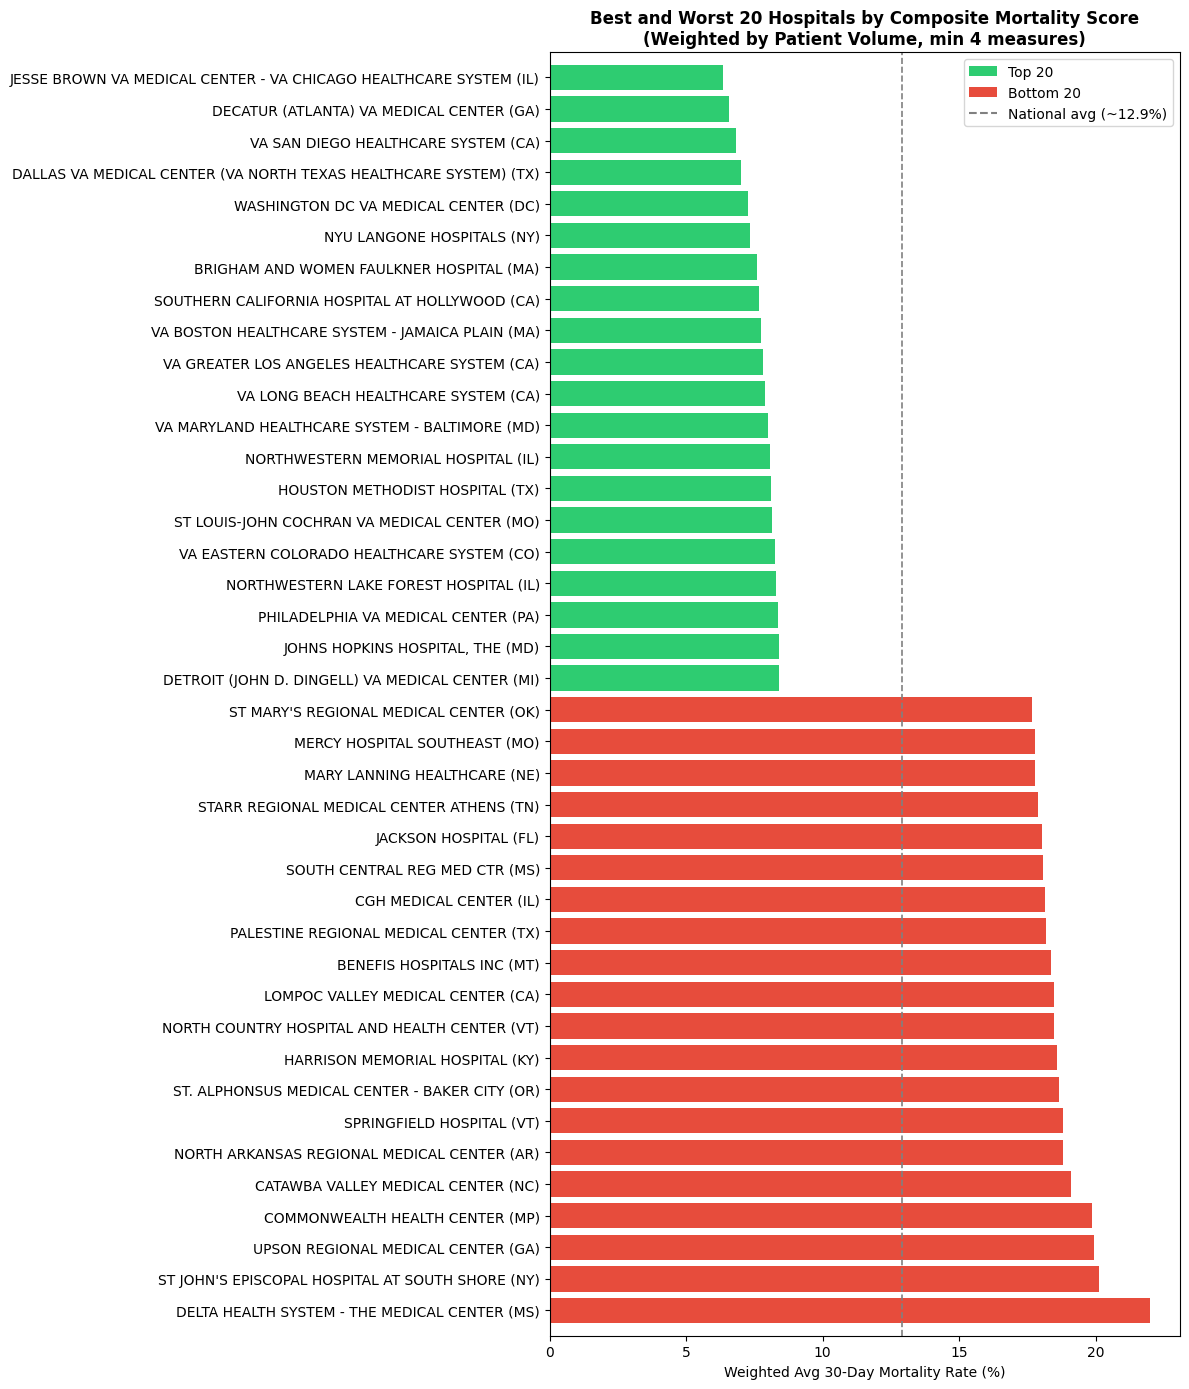

In [8]:
# Top 20 best and worst hospitals by composite mortality score
query = """
    WITH mortality_measures AS (
        SELECT 
            c."Facility ID",
            c."Facility Name",
            h."State",
            c."Measure ID",
            CAST(c."Score" AS FLOAT)         as score,
            CAST(c."Denominator" AS INTEGER)  as denominator
        FROM complications c
        JOIN hospitals h ON c."Facility ID" = h."Facility ID"
        WHERE c."Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                                  'MORT_30_STK', 'MORT_30_COPD')
          AND c."Score" NOT IN ('Not Available', 'Not Applicable')
          AND c."Denominator" NOT IN ('Not Available', 'Not Applicable')
    ),
    hospital_scores AS (
        SELECT
            "Facility Name" || ' (' || "State" || ')' as hospital,
            ROUND(SUM(score * denominator) / SUM(denominator), 2) as weighted_avg_mortality,
            COUNT(DISTINCT "Measure ID") as measures_available
        FROM mortality_measures
        GROUP BY "Facility ID", "Facility Name", "State"
        HAVING COUNT(DISTINCT "Measure ID") >= 4
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (ORDER BY weighted_avg_mortality ASC)  as best_rank,
            RANK() OVER (ORDER BY weighted_avg_mortality DESC) as worst_rank
        FROM hospital_scores
    )
    SELECT hospital, weighted_avg_mortality, 'Top 20' as category
    FROM ranked WHERE best_rank <= 20
    UNION ALL
    SELECT hospital, weighted_avg_mortality, 'Bottom 20' as category
    FROM ranked WHERE worst_rank <= 20
    ORDER BY weighted_avg_mortality ASC
"""

df = con.execute(query).df()

# Sort: best at top, worst at bottom
df_sorted = df.sort_values('weighted_avg_mortality', ascending=False)

fig, ax = plt.subplots(figsize=(12, 14))

colors = ['#e74c3c' if c == 'Bottom 20' else '#2ecc71' for c in df_sorted['category']]
ax.barh(df_sorted['hospital'], df_sorted['weighted_avg_mortality'], color=colors)

ax.axvline(x=12.9, color='gray', linestyle='--', linewidth=1.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Top 20'),
                   Patch(facecolor='#e74c3c', label='Bottom 20'),
                   plt.Line2D([0], [0], color='gray', linestyle='--', label='National avg (~12.9%)')]
ax.legend(handles=legend_elements)

ax.set_xlabel('Weighted Avg 30-Day Mortality Rate (%)')
ax.set_title('Best and Worst 20 Hospitals by Composite Mortality Score\n(Weighted by Patient Volume, min 4 measures)', 
             fontsize=12, fontweight='bold')

# Remove empty space
ax.margins(y=0.01)

plt.tight_layout()
plt.savefig('../figures/top_bottom_hospitals.png', dpi=150, bbox_inches='tight')
plt.show()

## Best and Worst 20 Hospitals by Composite Mortality Score

Comparing the top and bottom 20 hospitals reveals a striking gap: the best 
hospitals cluster around **6–9% weighted mortality**, while the worst reach 
**17–22%** — more than triple the rate of the top performers.

**Best performers** are dominated by VA hospitals and a handful of elite academic 
medical centers (NYU Langone, Brigham and Women's, Northwestern, Johns Hopkins).

**Worst performers** are concentrated in rural areas and southern states — 
Delta Health System (MS) ranks last at 22.3%, nearly 4x the rate of the 
#1 hospital (Jesse Brown VA, IL at 6.4%).

The national average (~12.9%) sits far closer to the worst performers than 
the best — suggesting that truly high-quality care is the exception, not the norm.



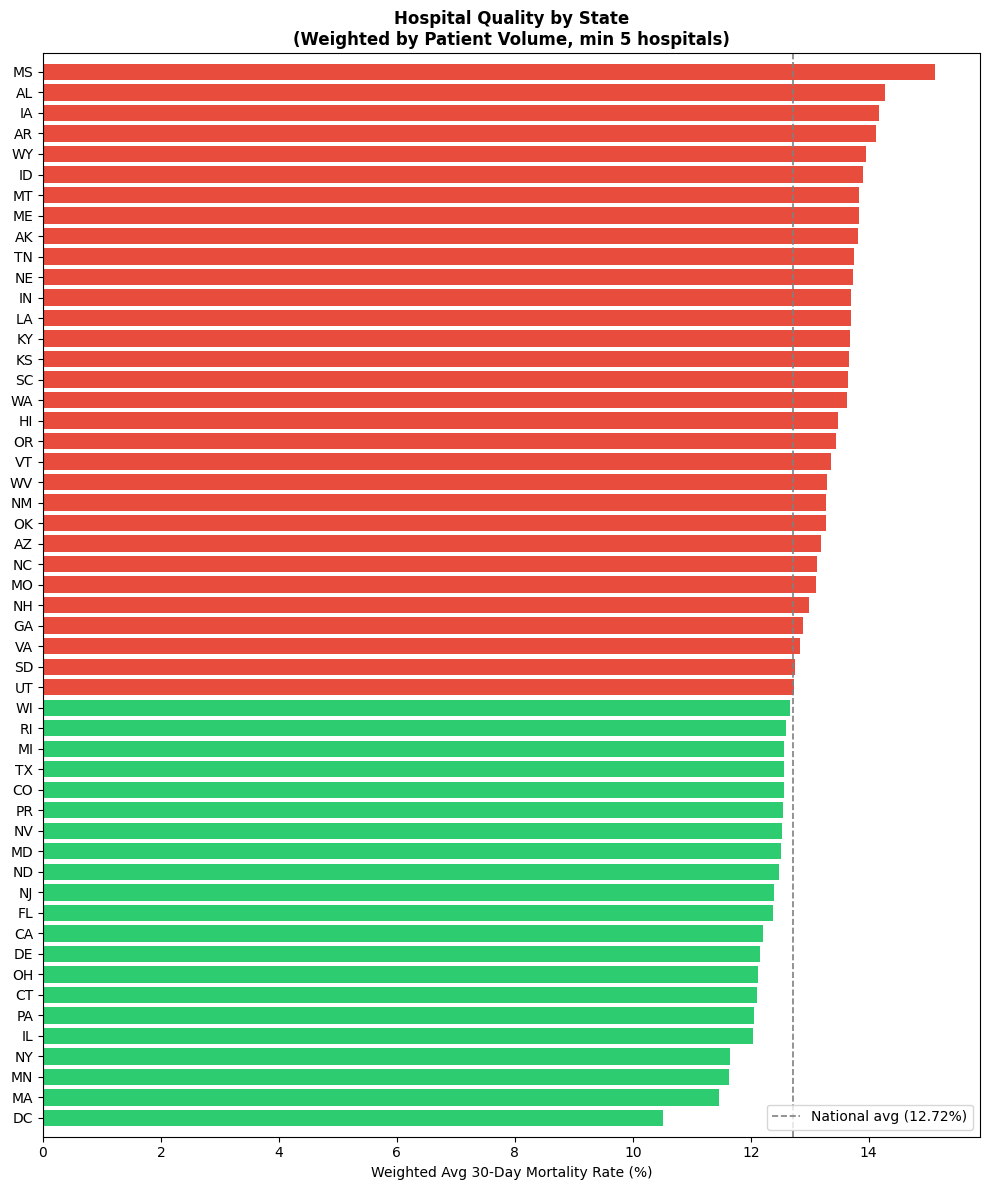

In [12]:
# Full state ranking — best to worst
state_ranking = con.execute("""
    WITH mortality_measures AS (
        SELECT 
            c."Facility ID",
            h."State",
            c."Measure ID",
            CAST(c."Score" AS FLOAT)         as score,
            CAST(c."Denominator" AS INTEGER)  as denominator
        FROM complications c
        JOIN hospitals h ON c."Facility ID" = h."Facility ID"
        WHERE c."Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                                  'MORT_30_STK', 'MORT_30_COPD')
          AND c."Score" NOT IN ('Not Available', 'Not Applicable')
          AND c."Denominator" NOT IN ('Not Available', 'Not Applicable')
    )
    SELECT
        "State",
        COUNT(DISTINCT "Facility ID")                                    as num_hospitals,
        ROUND(SUM(score * denominator) / SUM(denominator), 2)           as weighted_avg_mortality
    FROM mortality_measures
    GROUP BY "State"
    HAVING COUNT(DISTINCT "Facility ID") >= 5
    ORDER BY weighted_avg_mortality ASC
""").df()

NATIONAL_AVG = 12.72
# Plot
fig, ax = plt.subplots(figsize=(10, 12))

colors = ['#2ecc71' if x < NATIONAL_AVG else '#e74c3c' for x in state_ranking['weighted_avg_mortality']]
ax.barh(state_ranking['State'], state_ranking['weighted_avg_mortality'], color=colors)
ax.axvline(x=NATIONAL_AVG, color='gray', linestyle='--', linewidth=1.2, label=f'National avg ({NATIONAL_AVG}%)')
ax.set_xlabel('Weighted Avg 30-Day Mortality Rate (%)')
ax.set_title('Hospital Quality by State\n(Weighted by Patient Volume, min 5 hospitals)',
             fontsize=12, fontweight='bold')
ax.margins(y=0.01)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/state_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## Hospital Quality by State

Ranking all states by weighted average mortality reveals a clear geographic divide.

**Bottom performers:** Mississippi (15.1%), Alabama, Iowa, Arkansas — predominantly 
rural southern and midwestern states with limited access to specialized care.

**Top performers:** DC (10.6%), Massachusetts (11.5%), Minnesota (11.6%), 
New York (11.7%) — states with high concentrations of academic medical centers 
and urban health infrastructure.

Roughly half of states fall below the national average (~12.72%), suggesting 
that geographic location is a strong predictor of care quality — exactly the 
type of signal a provider recommendation engine needs to surface.

In [10]:
# Calculate our own benchmark explicitly
national_avg = con.execute("""
    SELECT ROUND(SUM(CAST("Score" AS FLOAT) * CAST("Denominator" AS INTEGER)) / 
                 SUM(CAST("Denominator" AS INTEGER)), 2) as national_weighted_avg
    FROM complications
    WHERE "Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                            'MORT_30_STK', 'MORT_30_COPD')
      AND "Score" NOT IN ('Not Available', 'Not Applicable')
      AND "Denominator" NOT IN ('Not Available', 'Not Applicable')
""").fetchone()[0]

print(f"National weighted average (our data): {national_avg}%")

National weighted average (our data): 12.72%


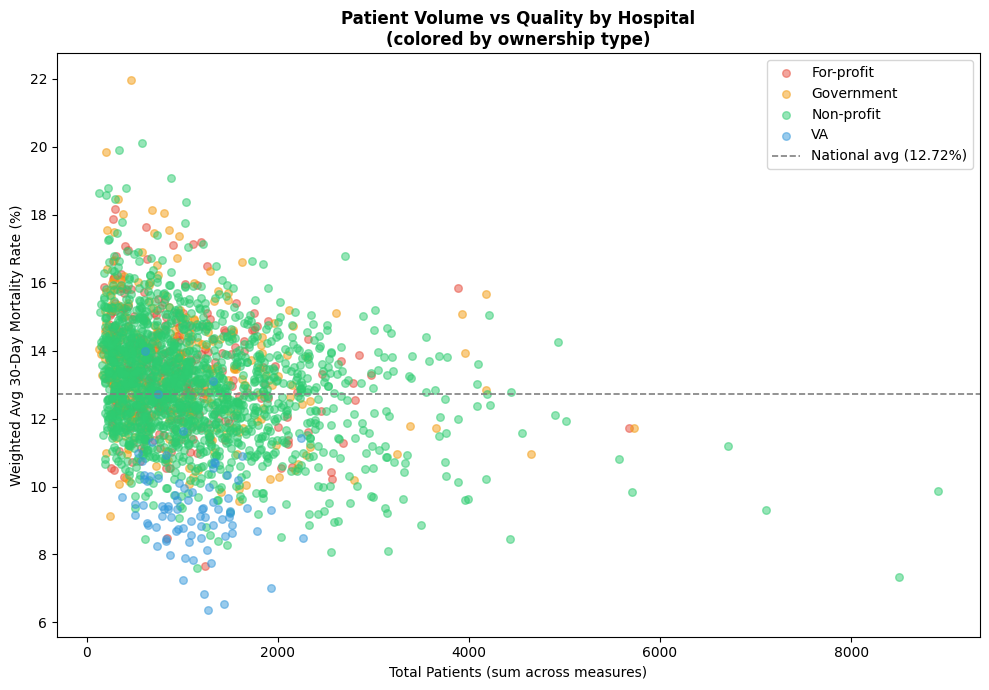

In [13]:
# Scatter: patient volume vs quality
scatter_data = con.execute("""
    WITH mortality_measures AS (
        SELECT 
            c."Facility ID",
            c."Facility Name",
            h."Hospital Ownership",
            c."Measure ID",
            CAST(c."Score" AS FLOAT)         as score,
            CAST(c."Denominator" AS INTEGER)  as denominator
        FROM complications c
        JOIN hospitals h ON c."Facility ID" = h."Facility ID"
        WHERE c."Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                                  'MORT_30_STK', 'MORT_30_COPD')
          AND c."Score" NOT IN ('Not Available', 'Not Applicable')
          AND c."Denominator" NOT IN ('Not Available', 'Not Applicable')
    )
    SELECT
        "Facility Name",
        CASE 
            WHEN "Hospital Ownership" LIKE '%Veterans%' THEN 'VA'
            WHEN "Hospital Ownership" LIKE '%non-profit%' THEN 'Non-profit'
            WHEN "Hospital Ownership" = 'Proprietary' THEN 'For-profit'
            ELSE 'Government'
        END as ownership_group,
        ROUND(SUM(score * denominator) / SUM(denominator), 2) as weighted_avg_mortality,
        SUM(denominator) as total_patients,
        COUNT(DISTINCT "Measure ID") as measures_available
    FROM mortality_measures
    GROUP BY "Facility ID", "Facility Name", "Hospital Ownership"
    HAVING COUNT(DISTINCT "Measure ID") >= 4
""").df()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'VA': '#3498db', 'Non-profit': '#2ecc71', 
              'For-profit': '#e74c3c', 'Government': '#f39c12'}

for group, data in scatter_data.groupby('ownership_group'):
    ax.scatter(data['total_patients'], data['weighted_avg_mortality'],
               c=colors_map[group], label=group, alpha=0.5, s=30)

ax.axhline(y=NATIONAL_AVG, color='gray', linestyle='--', linewidth=1.2, 
           label=f'National avg ({NATIONAL_AVG}%)')
ax.set_xlabel('Total Patients (sum across measures)')
ax.set_ylabel('Weighted Avg 30-Day Mortality Rate (%)')
ax.set_title('Patient Volume vs Quality by Hospital\n(colored by ownership type)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/volume_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Patient Volume vs Quality

The scatter plot reveals a clear pattern: **high-volume hospitals tend to have 
lower mortality rates**. The worst performers (top-left) are almost exclusively 
small hospitals with fewer than 500 patients across measures.

This volume-quality relationship is well-documented in clinical literature — 
hospitals that perform procedures more frequently develop greater expertise. 
It also highlights a key challenge for provider recommendation: small hospitals 
may have unreliable quality estimates due to small sample sizes.

**By ownership:** VA hospitals (blue) cluster consistently below the national 
average regardless of volume. For-profit hospitals (red) show the widest 
variance — some perform well, many do not.

In [14]:
# Mortality rate by condition — does the pattern hold across measures?
by_measure = con.execute("""
    SELECT 
        c."Measure ID",
        c."Measure Name",
        CASE 
            WHEN h."Hospital Ownership" LIKE '%Veterans%' THEN 'VA'
            WHEN h."Hospital Ownership" LIKE '%non-profit%' THEN 'Non-profit'
            WHEN h."Hospital Ownership" = 'Proprietary' THEN 'For-profit'
            ELSE 'Government'
        END as ownership_group,
        ROUND(SUM(CAST(c."Score" AS FLOAT) * CAST(c."Denominator" AS INTEGER)) / 
              SUM(CAST(c."Denominator" AS INTEGER)), 2) as weighted_avg_mortality,
        COUNT(DISTINCT c."Facility ID") as num_hospitals
    FROM complications c
    JOIN hospitals h ON c."Facility ID" = h."Facility ID"
    WHERE c."Measure ID" IN ('MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 
                              'MORT_30_STK', 'MORT_30_COPD')
      AND c."Score" NOT IN ('Not Available', 'Not Applicable')
      AND c."Denominator" NOT IN ('Not Available', 'Not Applicable')
    GROUP BY c."Measure ID", c."Measure Name", ownership_group
    ORDER BY c."Measure ID", weighted_avg_mortality ASC
""").df()

by_measure

,Measure ID,Measure Name,ownership_group,weighted_avg_mortality,num_hospitals
0,MORT_30_AMI,Death rate for heart attack patients,VA,11.29,81
1,MORT_30_AMI,Death rate for heart attack patients,Non-profit,12.00,1339
2,MORT_30_AMI,Death rate for heart attack patients,For-profit,12.14,321
3,MORT_30_AMI,Death rate for heart attack patients,Government,12.29,211
4,MORT_30_COPD,Death rate for COPD patients,VA,7.31,117
5,MORT_30_COPD,Death rate for COPD patients,Non-profit,8.66,1763
6,MORT_30_COPD,Death rate for COPD patients,Government,9.00,369
7,MORT_30_COPD,Death rate for COPD patients,For-profit,9.14,407
8,MORT_30_HF,Death rate for heart failure patients,VA,8.22,117
9,MORT_30_HF,Death rate for heart failure patients,Non-profit,10.94,2046


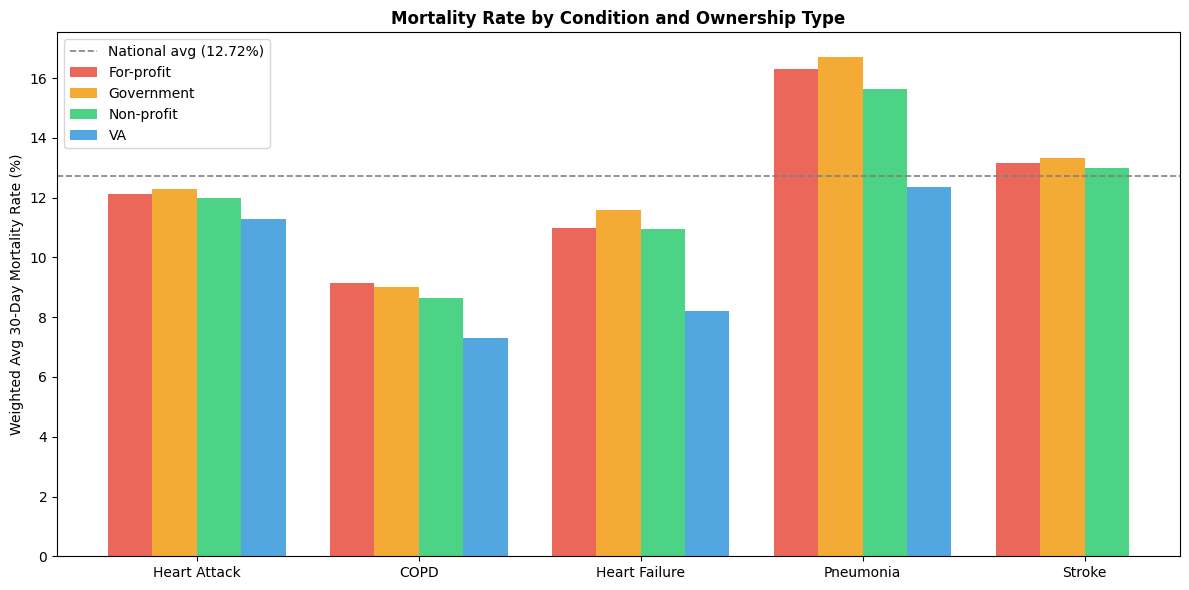

In [15]:
import numpy as np

# Pivot for plotting
pivot = by_measure.pivot(index='Measure ID', columns='ownership_group', values='weighted_avg_mortality')

# Shorter measure names for x axis
measure_labels = {
    'MORT_30_AMI': 'Heart Attack',
    'MORT_30_COPD': 'COPD',
    'MORT_30_HF': 'Heart Failure',
    'MORT_30_PN': 'Pneumonia',
    'MORT_30_STK': 'Stroke'
}
pivot.index = [measure_labels[i] for i in pivot.index]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot))
width = 0.2
colors_map = {'VA': '#3498db', 'Non-profit': '#2ecc71', 
              'For-profit': '#e74c3c', 'Government': '#f39c12'}

for i, col in enumerate(pivot.columns):
    ax.bar(x + i * width, pivot[col], width, 
           label=col, color=colors_map.get(col, 'gray'), alpha=0.85)

ax.axhline(y=NATIONAL_AVG, color='gray', linestyle='--', linewidth=1.2,
           label=f'National avg ({NATIONAL_AVG}%)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Weighted Avg 30-Day Mortality Rate (%)')
ax.set_title('Mortality Rate by Condition and Ownership Type',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/mortality_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
con.execute("""
    SELECT h."Hospital Ownership", COUNT(DISTINCT c."Facility ID") as n
    FROM complications c
    JOIN hospitals h ON c."Facility ID" = h."Facility ID"
    WHERE c."Measure ID" = 'MORT_30_STK'
      AND c."Score" NOT IN ('Not Available', 'Not Applicable')
      AND h."Hospital Ownership" LIKE '%Veterans%'
    GROUP BY h."Hospital Ownership"
""").df()

,Hospital Ownership,n


## Mortality Rate by Condition and Ownership Type

The VA advantage holds consistently across **all reported conditions** — 
COPD (7.31%), Heart Failure (8.22%), Heart Attack (11.29%) — always ranking 
#1 by ownership type.

**Pneumonia stands out** as the highest-mortality condition across all ownership 
types (12.3–16.7%), while COPD has the lowest rates overall.

Note: VA hospitals show no reportable stroke data (`MORT_30_STK`) — 
132 VA facilities appear in the dataset but are marked "Not Available" 
by CMS, likely due to low case volume per facility or separate VA 
reporting requirements. VA hospitals do treat stroke patients; 
in emergencies, veterans go to the nearest available hospital.

**For-profit hospitals** consistently rank last or second-to-last across all 
conditions where comparison is possible.

In [ ]:
con.execute("""
    SELECT "Compared to National", COUNT(*) as n
    FROM complications c
    JOIN hospitals h ON c."Facility ID" = h."Facility ID"
    WHERE c."Measure ID" = 'MORT_30_STK'
      AND h."Hospital Ownership" LIKE '%Veterans%'
    GROUP BY "Compared to National"
""").df()

In [20]:
con.close() #closing DB